# A-SIS implementation

In [50]:
import networkx as nx
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

import ndlib.models.ModelConfig as mc
import ndlib.models.epidemics as ep
import seaborn as sns
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field
from enum import auto, Enum
import random 

from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation


## N-Intertwined SIS Model for Epidemic Spread

Van Mieghem *et al.* [15] derived a set of ordinary differential equations, called the N-intertwined model, which represents the time evolution of the probability of infection for each individual. In this model, a network of $ N $ individuals is considered where each individual is represented by a node and the contact topology is represented by a graph $ \mathcal{G} $.

A disease in this model is characterized by **infection rate** $ \beta \in \mathbb{R}^{+} $ and **curing rate** $ \delta \in \mathbb{R}^{+} $. The N-intertwined model describes the time evolution of the infection probability of the $ i $-th individual, denoted by $ p_i \in [0,1] $, as:

$$
\dot{p}_i = \beta (1 - p_i) \sum_{j \in \mathcal{N}_i} a_{ij} p_j - \delta p_i, \quad i \in \{1, \dots, N\}
$$

where $ a_{ij} > 0 $ if individual $ j $ can potentially infect individual $ i $, i.e. $ j \in \mathcal{N}_i $, otherwise $ a_{ij} = 0 $.


In [18]:
def sis_model(p, t, A, beta, delta):
    return beta * (1 - p) * (A @ p) - delta * p

Define a new state $ x_i \triangleq [s_i, p_i, q_i]^T $, where $ s_i, p_i $, and $ q_i $ denote the probabilities of individual $ i $ to be susceptible, infected, and alert, respectively. According to (5), **the time evolution of $ x_i $ can be described by the following differential equations**:

$$
\dot{x}_i = \Theta_i^T x_i, \quad i \in \{1, \ldots, N\},
$$

where

$$
\Theta_i \triangleq
\begin{bmatrix}
-\delta & 0 & \delta \\
\beta a y_i & -\beta a y_i & 0 \\
\beta y_i & \kappa y_i & -(\beta + \kappa) y_i
\end{bmatrix}
$$

is the **infinitesimal transition matrix**, and $ y_i \triangleq \sum_{j \in \mathcal{N}_i} a_{ij} p_j $.

One property of the dynamic system (6) is that $ s_i + p_i + q_i $ is a preserved quantity. Hence, **the states $ s_i, p_i $, and $ q_i $ are not independent**.

Omitting $ s_i $ in (6), the SAIS spreading model is obtained as:

$$
\dot{p}_i = \beta (1 - p_i - q_i) \sum_{j \in \mathcal{N}_i} a_{ij} p_j + \beta a q_i \sum_{j \in \mathcal{N}_i} a_{ij} p_j - \delta p_i,
$$

$$
\dot{q}_i = \kappa (1 - p_i - q_i) \sum_{j \in \mathcal{N}_i} a_{ij} p_j - \beta a q_i \sum_{j \in \mathcal{N}_i} a_{ij} p_j,
$$

for $ i \in \{1, \ldots, N\} $.


In [13]:
def sais_model(y, t, A, beta, beta_a, delta, kappa):
    N = A.shape[0]
    p = y[:N]
    q = y[N:]
    dpdt = np.zeros(N)
    dqdt = np.zeros(N)

    for i in range(N):
        yi = sum(A[i, j] * p[j] for j in range(N))
        dpdt[i] = beta * (1 - p[i] - q[i]) * yi + beta_a * q[i] * yi - delta * p[i]
        dqdt[i] = kappa * (1 - p[i] - q[i]) * yi - beta_a * q[i] * yi
    return np.concatenate([dpdt, dqdt])

In [14]:
def simulate_sais(A, beta, beta_a, delta, kappa, p0_init, t):
    N = A.shape[0]
    q0 = np.zeros(N)
    y0 = np.concatenate([p0_init, q0])
    sol = odeint(sais_model, y0, t, args=(A, beta, beta_a, delta, kappa))
    p_sol = sol[:, :N]
    return p_sol.mean(axis=1)

![fig2](fig2.png)

In order to examine the analytical results developed for the SAIS spreading model, three examples are provided in this section. In all of the simulations, **the curing rate is fixed at** $ \delta = 1 $ **so that the dimensionless time** $ \bar{t} = \delta t $ **is the same as the simulat**

**We consider an arbitrary contact graph with 11 nodes and 16 links.** For this network, the **spectral radius is found to be** $ \rho(A) = 3.1385 $. For the simulation purpose, **three nodes are initialized in the infected state while others are all susceptible.**

In **Fig. 2**, three trajectories of the total infection fraction $ \bar{p}(t) = \frac{1}{N} \sum_{i=1}^{N} p_i(t) $ are plotted. For all the three, $ \kappa = 0.1 $ and $ \beta_a = 0.1 $. The trajectories (a) and (b) correspond to the N-intertwined SIS model (1) and the SAIS spreading model (8) and (9), respectively, with $ \beta = 2 $. **Trajectory (c) is the solution of the SIS model with the infection rate $ \beta_{\text{eff}} $ defined in (26).**

As is expected from Theorem 1, the infected fraction in SIS model always dominates the SAIS model. In addition, as proved in Theorem 4, the steady state infection fraction in the SAIS is equal to that of the SIS model with the effective infection rate $ \beta_{\text{eff}} $. In **Fig. 2**, it can be observed that **the infection probabilities in the SAIS model spread similar to the SIS model at the first stage. Then, the size of the epidemics is reduced due to increased alertness in the network.**


In [77]:
N = 11 # 11 nodes
A = np.zeros((N, N))
edges = [(0, 1), (0, 4), (0, 5), (1, 2), (2, 3), (2, 6), (3, 4), (4, 7),
         (5, 8), (6, 9), (7, 10), (8, 9), (9, 10), (1, 9), (3, 8), (5, 7)] # 16 links

for i, j in edges:
    A[i, j] = A[j, i] = 1

beta, beta_a, delta, kappa = 2, 0.1, 1, 0.1
p0 = np.zeros(N)
p0[[0, 5, 10]] = 1
t = np.linspace(0, 25, 200)

p_sais = simulate_sais(A, beta, beta_a, delta, kappa, p0, t)

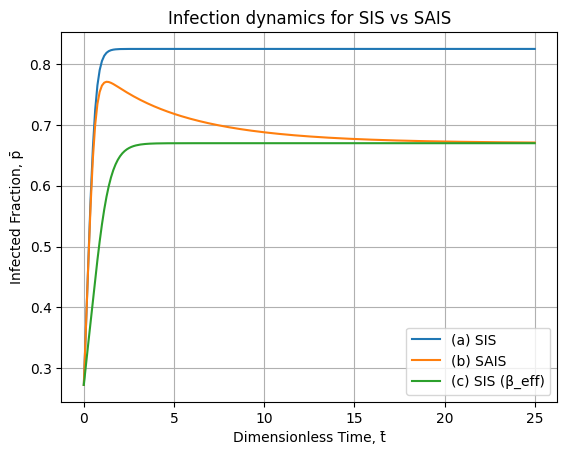

In [78]:
sis_sol = odeint(sis_model, p0, t, args=(A, beta, delta))
p_sis = sis_sol.mean(axis=1)

beta_eff = beta * (beta_a / kappa) / (1 + beta_a / kappa) + beta_a / (1 + beta_a / kappa)

sis_eff_sol = odeint(sis_model, p0, t, args=(A, beta_eff, delta))
p_sis_eff = sis_eff_sol.mean(axis=1)

plt.figure()
plt.plot(t, p_sis, label='(a) SIS')
plt.plot(t, p_sais, label='(b) SAIS')
plt.plot(t, p_sis_eff, label='(c) SIS (β_eff)')
plt.xlabel('Dimensionless Time, t̄')
plt.ylabel('Infected Fraction, p̄')
plt.legend()
plt.title('Infection dynamics for SIS vs SAIS')
plt.grid()
plt.show()

*Example 2:* In this example, for the same network in the previous example, (1) **the steady state value of the infected fraction** and (2) **the maximum value of the infected fraction** are plotted as a function of the infection strength $ \tau = \beta / \delta $. The simulation parameters are chosen as $ \kappa = 1 $, $ \beta_a = 0.1 $.


![fig3](fig3.png)

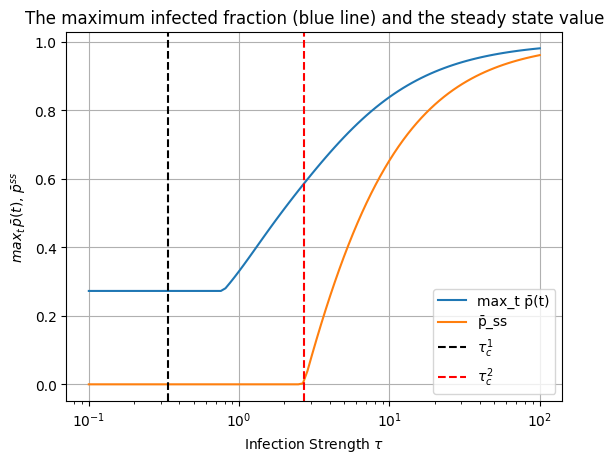

In [41]:
tau_vals = np.logspace(-1, 2, 100)
max_p, ss_p = [], []
kappa = 1
beta_a = 0.1
t = np.linspace(0,500, 400)

for tau in tau_vals:
    beta = tau * delta
    p_sol = simulate_sais(A, beta, beta_a, delta, kappa, p0, t)
    max_p.append(max(p_sol))
    ss_p.append(p_sol[-1])

plt.figure()
plt.plot(tau_vals, max_p, label='max_t p̄(t)')
plt.plot(tau_vals, ss_p, label='p̄_ss')
plt.axvline(x=1 / max(np.linalg.eigvals(A)), color='k', linestyle='--', label=rf'$\tau_c^1$')
tau2 = 1 / max(np.linalg.eigvals(A)) + kappa / beta_a * (1 / max(np.linalg.eigvals(A)) - beta_a / delta)
plt.axvline(x=tau2, color='r', linestyle='--', label=rf'$\tau_c^2$')
plt.xscale('log')
plt.xlabel(rf'Infection Strength $\tau$')
plt.ylabel(r'$max_t\,\bar{p}(t)$, $\bar{p}^{ss}$')
plt.legend()
plt.title('The maximum infected fraction (blue line) and the steady state value')
plt.grid()
plt.show()


Consider an epidemic network where the contact graph is an Erdos–Reyni random graph with **$N = 320$ nodes** and **connection probability $p = 0.2$**.  
The **initial infected population is 2%** of the whole population.  
The **simulation parameters are** $ \beta = 0.03 $, $ \kappa = 0.05 $.  

Three trajectories (a), (b), and (c) are presented in Fig. 4 corresponding to:

- $ \beta_a = \beta $  
- $ \beta_a = 0.02 $  
- $ \beta_a = 0.01 $

For the sake of evaluating the model development in Section II, a **Monte-Carlo simulation is also provided for each trajectory, shown in Fig. 4 in blue**.

As can be seen, there is a reasonable agreement between the proposed model (8) and (9) and the Markov process (4).  
It can be observed that **lowering $ \beta_a $ reduces the steady state infection probability**.  
For a sufficiently small value of $ \beta_a $, infection is mitigated totally at the steady state.


![fig4](fig4.png)

In [45]:
N = 320
p_edge = 0.2
G = nx.erdos_renyi_graph(N, p_edge)
A = nx.to_numpy_array(G)

p0 = np.zeros(N)
infected_indices = np.random.choice(N, size=int(0.02 * N), replace=False)
p0[infected_indices] = 1

t = np.linspace(0, 25, 300)
beta = 0.03
delta = 1
kappa = 0.05

beta_a_values = [0.03, 0.02, 0.01]

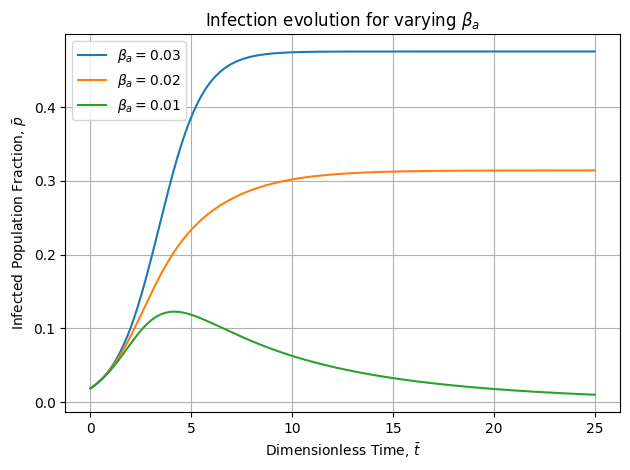

In [47]:
plt.figure()
for beta_a in beta_a_values:
    p_avg = simulate_sais(A, beta, beta_a, delta, kappa, p0, t)
    plt.plot(t, p_avg, label=rf'$\beta_a = {beta_a:.2f}$')

plt.xlabel('Dimensionless Time, $\\bar{{t}}$')
plt.ylabel('Infected Population Fraction, $\\bar{{p}}$')
plt.title('Infection evolution for varying $\\beta_a$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Simulations - graphs

In [74]:
class StateAlertSpreadingSAIS(Enum):
    suspectible = auto()
    infected = auto()
    alert = auto()

class ParamsSAIS(BaseModel):
    beta: float = Field(..., gt=0, lt=1)
    beta_a: float = Field(..., gt=0, lt=1)
    delta: float = Field(..., gt=0, le=1)
    kappa: float = Field(..., gt=0, lt=1)

In [75]:
class SAIS:
    state_color_mapping = {
        StateAlertSpreadingSAIS.suspectible: "blue",
        StateAlertSpreadingSAIS.infected: "red",
        StateAlertSpreadingSAIS.alert: "yellow",
    }
    
    def __init__(
        self,
        graph: nx.Graph,
        params: ParamsSAIS,
        pos_seed: int = 3
    ) -> None:
        self.graph = graph
        self.pos = nx.spring_layout(self.graph, seed=pos_seed)
        self.params = params
    
    def init_state(self, I0: int, seed: int):
        random.seed(seed)
        np.random.seed(seed=seed)
        nx.set_node_attributes(self.graph, StateAlertSpreadingSAIS.suspectible, "state")
        nx.set_node_attributes(
            self.graph,
            {
                node: {"state": StateAlertSpreadingSAIS.infected}
                for node in random.sample(list(self.graph.nodes), k=I0)
            }
        )
    
    def _update_state(self):
        """Asynchronous updates considered."""
        node_states = nx.get_node_attributes(self.graph, "state")
        infected_nodes = [n for n, state in node_states.items() if state == StateAlertSpreadingSAIS.infected]
        next_states = {}

        trans_IS = np.random.random(len(infected_nodes)) <= self.params.delta
        recovered = {node: StateAlertSpreadingSAIS.suspectible for node, is_change in zip(infected_nodes, trans_IS) if is_change}
        dangered_suscteptible = [v for u in infected_nodes for v in self.graph.neighbors(u) if node_states[v] == StateAlertSpreadingSAIS.suspectible]
        trans_SA = np.random.random(len(dangered_suscteptible)) <= self.params.kappa
        alerted = {node: StateAlertSpreadingSAIS.alert for node, is_change in zip(dangered_suscteptible, trans_SA) if is_change}
        trans_SI = np.random.random(len(dangered_suscteptible)) <= self.params.beta
        infected = {node: StateAlertSpreadingSAIS.infected for node, is_change in zip(dangered_suscteptible, trans_SI) if is_change}
        dangered_alert = [v for u in infected_nodes for v in self.graph.neighbors(u) if node_states[v] == StateAlertSpreadingSAIS.alert]
        trans_AI = np.random.random(len(dangered_alert)) <= self.params.beta_a
        infected_in_alert = {node: StateAlertSpreadingSAIS.infected for node, is_change in zip(dangered_alert, trans_AI) if is_change}

        next_states.update(recovered)
        #Infections should overwrite alerts
        next_states.update(alerted)
        next_states.update(infected)
        next_states.update(infected_in_alert)
        nx.set_node_attributes(self.graph, {node: {"state": state} for node, state in next_states.items()})


    def run_simulation(self, max_steps: int):
        statistics = {
            "infected_count": [],
            "suspectible_count": [],
            "alert_count": [],
        }
        is_finished = False
        step_no = 0
        while not is_finished and step_no < max_steps:
            self._update_state()
            states = nx.get_node_attributes(self.graph, "state").values()
            statistics["infected_count"].append(
                sum(1 for s in states if s == StateAlertSpreadingSAIS.infected)
            )
            statistics["suspectible_count"].append(
                sum(1 for s in states if s == StateAlertSpreadingSAIS.suspectible)
            )
            statistics["alert_count"].append(
                sum(1 for s in states if s == StateAlertSpreadingSAIS.alert)
            )
            step_no += 1
            is_finished = SAIS.is_finished(self.graph)
        return statistics

    @staticmethod
    def is_finished(graph: nx.Graph) -> bool:
        states = nx.get_node_attributes(graph, "state").values()
        total_infected = (
                sum(1 for s in states if s == StateAlertSpreadingSAIS.infected)
        )
        return len(graph) == total_infected or total_infected == 0



    def _get_nodes_state_mapping(self) -> list[int]:
        return [self.state_color_mapping[s] for s in nx.get_node_attributes(self.graph,'state').values()]        
    
    def _plot_current_state(self, ax):
        ax.clear()
        nx.draw_networkx(
            self.graph, 
            pos=self.pos, 
            with_labels=False, 
            node_color=self._get_nodes_state_mapping(),
            node_size=7,
            edge_color='gray',
            width=0.3,
            alpha=0.8,
            ax=ax
        )
        ax.set_title(f"SAIS model on the graph")
        ax.set_axis_off()

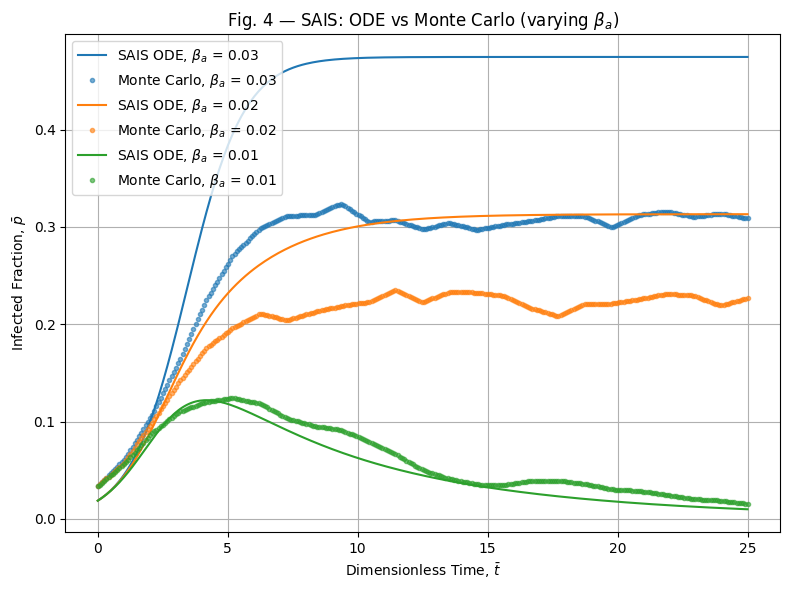

In [ ]:
def run_monte_carlo_average(graph, params, repetitions = 20, t = np.linspace(0, 25, 300), I0 = 6, seed_base = 42):
    mc_avg = np.zeros(len(t))
    steps = int(t[-1])

    for i in range(repetitions):
        sais = SAIS(graph=graph.copy(), params=params)
        sais.init_state(I0=I0, seed=seed_base + i)
        stats = sais.run_simulation(max_steps=steps)

        infected = np.array(stats["infected_count"]) / graph.number_of_nodes()

        time_mc = np.linspace(0, steps, len(infected))

        infected_interp = np.interp(t, time_mc, infected)

        mc_avg += infected_interp

    return mc_avg / repetitions


N = 320
p_edge = 0.2
G = nx.erdos_renyi_graph(N, p_edge)
A = nx.to_numpy_array(G)
t = np.linspace(0, 25, 300)
beta = 0.03
delta = 1
kappa = 0.05
p0 = np.zeros(N)
p0[np.random.choice(N, size=6, replace=False)] = 1

beta_a_values = [0.03, 0.02, 0.01]
colors = ['tab:blue', 'tab:orange', 'tab:green']

plt.figure(figsize=(8, 6))

for beta_a, color in zip(beta_a_values, colors):
    p_avg_ode = simulate_sais(A, beta, beta_a, delta, kappa, p0, t)
    label_ode = rf"SAIS ODE, $\beta_a$ = {beta_a:.2f}"
    plt.plot(t, p_avg_ode, label=label_ode, color=color)

    params = ParamsSAIS(beta=beta, beta_a=beta_a, delta=delta, kappa=kappa)
    mc_avg = run_monte_carlo_average(graph=G, params=params, repetitions=10, t=t, I0=6)
    label_mc = rf"Monte Carlo, $\beta_a$ = {beta_a:.2f}"
    plt.plot(t, mc_avg, 'o', markersize=3, color=color, alpha=0.6, label=label_mc)

plt.xlabel("Dimensionless Time, $\\bar{t}$")
plt.ylabel("Infected Fraction, $\\bar{p}$")
plt.title("Fig. 4 — SAIS: ODE vs Monte Carlo (varying $\\beta_a$)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
